In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Show more columns when printing tables
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

def find_file(filename):
    """
    Find a data file in the current directory.
    """
    candidates = [
        Path(filename),
        Path(".") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {filename}."
    )

WITH_CHAIN = find_file("data/chain_r31_job23716727_with_sBBN.1.txt")

NO_CHAIN = find_file("data/chain_r43_job25622034_without_sBBN.1.txt")

print("With-sBBN chain:", WITH_CHAIN)
print("No-sBBN chain  :", NO_CHAIN)

With-sBBN chain: data/chain_r31_job23716727_with_sBBN.1.txt
No-sBBN chain  : data/chain_r43_job25622034_without_sBBN.1.txt


In [4]:
def read_cobaya_chain(path):
    path = Path(path)
    with open(path, "r") as f:
        header = f.readline()
    columns = header.lstrip("#").split()
    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        names=columns,
        engine="python",
    )
    return df

chain_with = read_cobaya_chain(WITH_CHAIN)
chain_no = read_cobaya_chain(NO_CHAIN)

print("with sBBN:", chain_with.shape)
print("no sBBN  :", chain_no.shape)
print("\nFirst columns:")
display(chain_with.head())

with sBBN: (18567, 58)
no sBBN  : (25129, 58)

First columns:


,weight,minuslogpost,logA,n_s,H0,tau_reio,omega_b,omega_cdm,DES_DzL1,DES_DzL2,DES_DzL3,DES_DzL4,DES_DzL5,DES_b1,DES_b2,DES_b3,DES_b4,DES_b5,DES_DzS1,DES_DzS2,DES_DzS3,DES_DzS4,DES_m1,DES_m2,DES_m3,DES_m4,DES_AIA,DES_alphaIA,Omega_m,omegamh2,Omega_Lambda,A_s,YHe,z_reio,sigma8,s8h5,s8omegamp5,s8omegamp25,A,clamp,age,rs_drag,theta_star_100,z_star,rs_star,da_star,z_d,z_eq,k_eq,S8,omegamh3,rs_d_h,minuslogprior,minuslogprior__0,chi2,chi2__des_y1.clustering,chi2__des_y1.shear,chi2__des_y1.galaxy_galaxy
0,2,241.01153,3.049307,0.975359,68.144935,0.063167,0.022338,0.119274,-0.001976,-0.002418,-0.000314,0.002525,-0.005681,1.392815,1.534077,1.688501,1.889749,1.949123,0.039251,-0.016531,0.015072,-0.014657,0.008762,0.016516,0.017411,0.027816,0.939737,1.192113,0.306339,0.142256,0.693583,2.110072e-09,0.245559,8.561478,0.814448,0.986612,0.450780,0.605918,2.110072,1.859651,13.747869,147.25912,1.045913,1084.3358,145.06625,12.779287,1059.7651,3378.9446,0.010322,0.823008,0.096940,100.34963,-32.592737,-32.592737,547.20853,102.839660,235.85479,208.51408
1,3,229.13244,3.049291,0.976850,69.171981,0.061457,0.022341,0.119345,0.006694,-0.001162,0.003709,-0.004671,-0.013976,1.334102,1.536482,1.620321,2.008833,1.924508,0.021206,-0.016956,0.000892,-0.017709,0.007513,0.019507,0.024426,0.029406,0.800817,1.181244,0.297464,0.142330,0.702460,2.110037e-09,0.245561,8.400742,0.817977,0.983504,0.446127,0.604088,2.110037,1.865990,13.655647,147.23669,1.048937,1084.4931,145.03180,12.737581,1059.7794,3380.7080,0.010327,0.814513,0.098452,101.84653,-33.228042,-33.228042,524.72097,94.776771,232.02966,197.91454
2,6,225.22221,3.048450,0.976623,70.012090,0.059964,0.022253,0.119613,0.007387,0.001173,0.002823,-0.002638,-0.010380,1.339636,1.562749,1.633693,2.037057,1.917751,0.017460,-0.017442,0.001829,-0.011011,0.007936,0.029458,0.012211,0.021099,0.849306,1.327152,0.290737,0.142510,0.709189,2.108264e-09,0.245525,8.285629,0.821543,0.981847,0.442977,0.603261,2.108264,1.869998,13.578091,147.26293,1.051846,1084.7652,145.01744,12.697905,1059.6018,3385.0219,0.010340,0.808761,0.099775,103.10186,-34.305904,-34.305904,519.05623,89.856990,229.82094,199.37830
3,3,223.31388,3.048092,0.977476,70.046208,0.059176,0.022286,0.119475,0.000335,0.007493,0.002798,-0.001993,-0.020028,1.490686,1.635851,1.665492,2.023803,1.925906,0.020492,-0.023352,0.002855,0.003299,0.003324,0.026674,0.014094,0.020996,0.842155,1.092124,0.290239,0.142405,0.709687,2.107510e-09,0.245538,8.197189,0.820929,0.980874,0.442266,0.602552,2.107510,1.872278,13.577952,147.26311,1.051671,1084.7812,145.02208,12.700241,1059.6665,3382.5047,0.010332,0.807463,0.099749,103.15223,-32.268204,-32.268204,511.16418,81.927585,229.83501,199.40158
4,1,222.36995,3.048072,0.977409,69.917480,0.058897,0.022285,0.119500,0.001504,0.005562,0.002433,-0.003537,-0.018702,1.498401,1.686982,1.683085,2.027924,1.957585,0.023311,-0.016850,0.001381,-0.004431,0.003318,0.031865,0.013239,0.020570,0.782272,1.271158,0.291359,0.142429,0.708567,2.107468e-09,0.245538,8.169113,0.820681,0.981480,0.442984,0.602950,2.107468,1.873282,13.588384,147.25717,1.051302,1084.8097,145.01383,12.703638,1059.6672,3383.0888,0.010334,0.808775,0.099583,102.95850,-32.452770,-32.452770,509.64543,79.055936,230.63942,199.95008


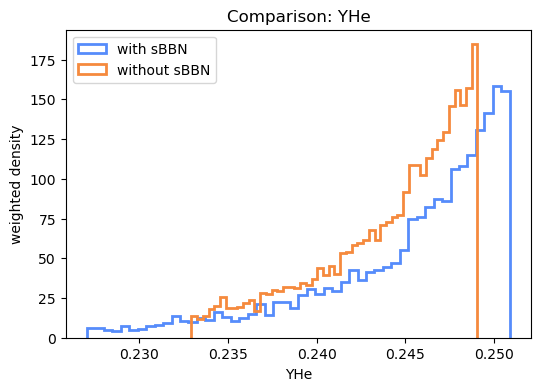

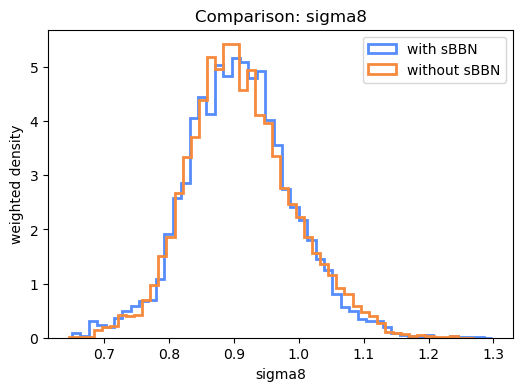

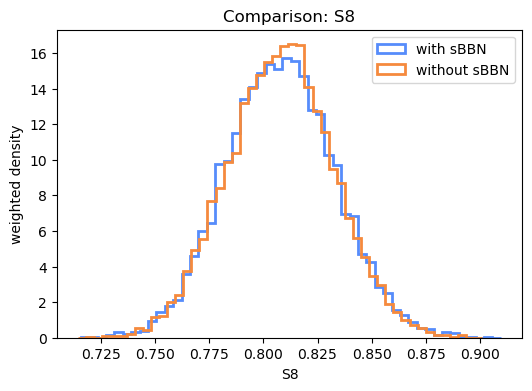

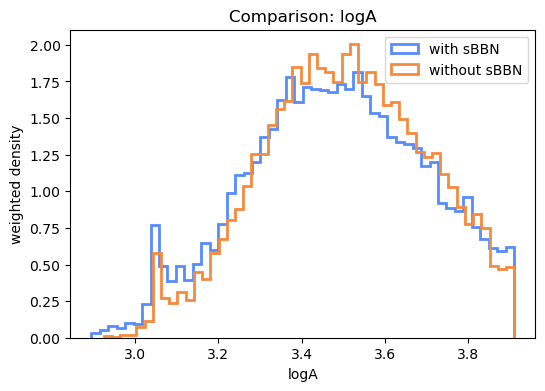

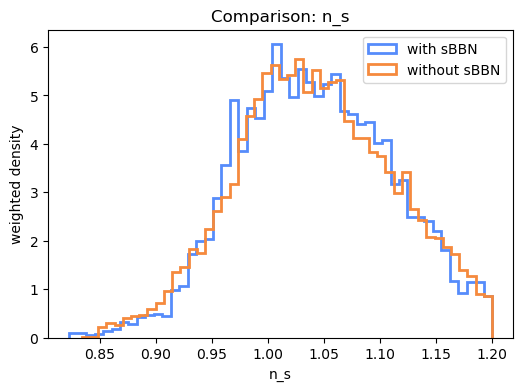

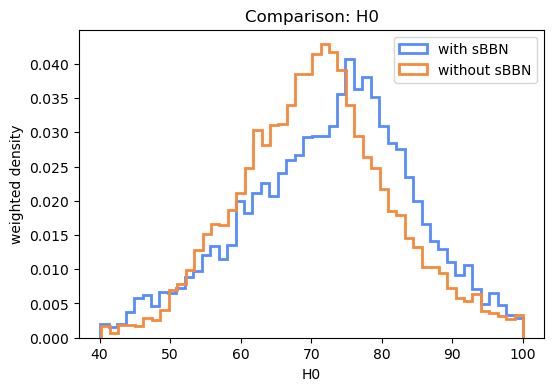

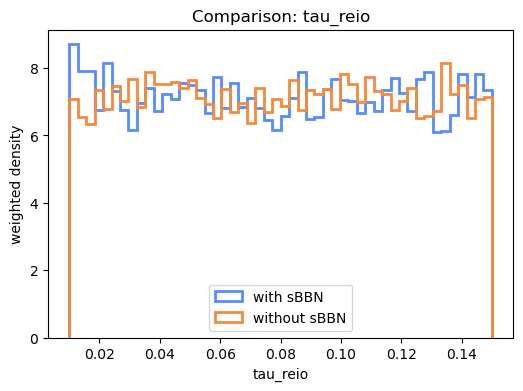

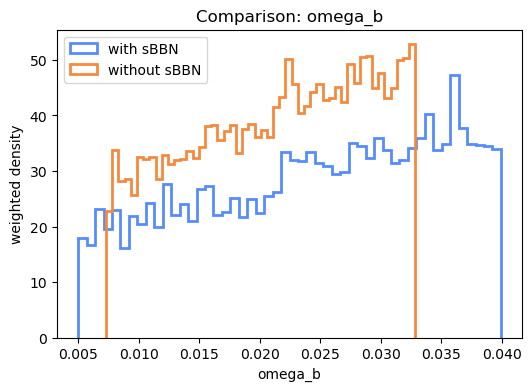

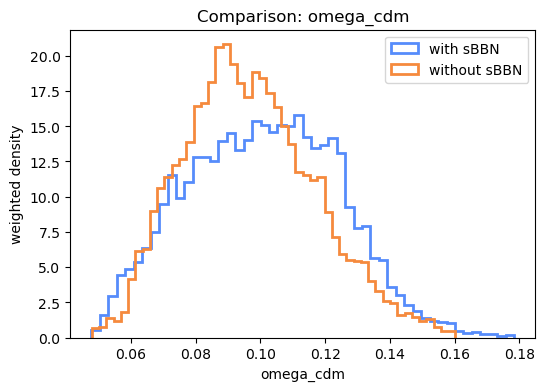

In [11]:
def weighted_hist(ax, df, col, label, bins=50):
    ax.hist(
        df[col],
        bins=bins,
        weights=df["weight"],
        density=True,
        histtype="step",    # "stepfilled"
        linewidth=2,
        label=label,
    )
    ax.set_xlabel(col)
    ax.set_ylabel("weighted density")
    ax.legend()

for col in ["YHe", "sigma8", "S8", "logA", "n_s", "H0", "tau_reio", "omega_b", "omega_cdm"]:
    fig, ax = plt.subplots(figsize=(6, 4))
    weighted_hist(ax, chain_with, col, "with sBBN")
    weighted_hist(ax, chain_no, col, "without sBBN")
    ax.set_title(f"Comparison: {col}")
    plt.show()